# Deep Learning: A Comprehensive Guide

## Chapter 6 — Midpoint Integration: Consolidating Perception Components

### Hands-On Exploration: The Vision Pipeline Audit

### `hands_on_ch6.ipynb`

This activity is the practical implementation of the chapter's audit framework. You will evaluate your MIPDS vision pipeline systematically — not to celebrate what it gets right, but to characterize precisely where it works, where it fails, and what those failures reveal. The deliverable is a completed model card and interface specification for the MIPDS vision module.

## Learning Objectives

By the end of this notebook, you should be able to:

- Produce a full evaluation report (accuracy, per-class accuracy, confusion matrix, calibration) for a trained vision model
- Conduct a systematic error analysis and form falsifiable hypotheses about failure patterns
- Visualize a model's learned representation space with t-SNE and interpret unexpected neighbor structures
- Write a complete, honest model card and interface specification

## Prerequisites

- Python 3.9+, `numpy`, `matplotlib`, `scikit-learn`
- `tensorflow` (this notebook trains a small vision model in-notebook so the evaluation harness is meaningful without requiring your actual Chapter 4 checkpoint — swap in your real model if you have one)
- No GPU required

## About the Model in This Notebook

The chapter's activity assumes you already have a fine-tuned ResNet-50 or EfficientNet-B0 from Chapter 4. To keep this notebook fully self-contained and runnable anywhere, we train a small CNN from scratch on a synthetic multi-class image dataset (the same shape-generation approach as Chapter 1) and run the full evaluation harness against it. **If you have your own trained model from Chapter 4, replace the `model` variable below with it** and everything downstream — confusion matrix, calibration, t-SNE, model card — will reflect your actual system.

## Setup — Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)

%matplotlib inline

TF_AVAILABLE = False
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    TF_AVAILABLE = True
    tf.random.set_seed(SEED)
except ImportError:
    print("TensorFlow not installed. Install with: pip install tensorflow")


I0000 00:00:1788477931.418695    1356 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788477931.571183    1356 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788477933.456117    1356 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Build a Small Evaluation Dataset and Model

We reuse a shape-classification task (5 classes this time, to make the confusion matrix and t-SNE plots more interesting) with train and held-out test splits.

In [2]:
IMG_SIZE = 32
CLASSES = ["circle", "square", "triangle", "star", "cross"]


def draw_shape(shape, size, cx, cy, rotation_deg, noise_std, canvas_size=IMG_SIZE, seed=0):
    rng = np.random.RandomState(seed)
    img = Image.new("L", (canvas_size, canvas_size), color=255)
    draw = ImageDraw.Draw(img)

    def rot(points):
        angle = np.radians(rotation_deg)
        ca, sa = np.cos(angle), np.sin(angle)
        return [(x * ca - y * sa + cx, x * sa + y * ca + cy) for x, y in points]

    if shape == "circle":
        draw.ellipse([cx - size, cy - size, cx + size, cy + size], fill=0)
    elif shape == "square":
        draw.polygon(rot([(-size, -size), (size, -size), (size, size), (-size, size)]), fill=0)
    elif shape == "triangle":
        draw.polygon(rot([(0, -size * 1.15), (size, size * 0.85), (-size, size * 0.85)]), fill=0)
    elif shape == "star":
        pts = []
        for i in range(10):
            r = size if i % 2 == 0 else size * 0.45
            a = np.pi / 5 * i
            pts.append((r * np.sin(a), -r * np.cos(a)))
        draw.polygon(rot(pts), fill=0)
    elif shape == "cross":
        w = size * 0.35
        pts = [(-w, -size), (w, -size), (w, -w), (size, -w), (size, w), (w, w),
               (w, size), (-w, size), (-w, w), (-size, w), (-size, -w), (-w, -w)]
        draw.polygon(rot(pts), fill=0)

    arr = np.array(img).astype(np.float32) / 255.0
    if noise_std > 0:
        arr = np.clip(arr + rng.normal(0, noise_std, arr.shape), 0, 1)
    return arr


def generate_split(n_per_class, seed, hard=False):
    rng = np.random.RandomState(seed)
    images, labels = [], []
    for shape in CLASSES:
        for i in range(n_per_class):
            size = rng.uniform(7, 11)
            cx = IMG_SIZE / 2 + rng.uniform(-3, 3)
            cy = IMG_SIZE / 2 + rng.uniform(-3, 3)
            rotation = rng.uniform(0, 45) if not hard else rng.uniform(0, 90)
            noise = 0.03 if not hard else 0.10
            img = draw_shape(shape, size, cx, cy, rotation, noise, seed=seed * 1000 + i)
            images.append(img)
            labels.append(shape)
    return np.array(images), np.array(labels)


X_train_imgs, y_train_labels = generate_split(120, seed=1)
X_test_imgs, y_test_labels = generate_split(40, seed=2, hard=True)

label_to_idx = {c: i for i, c in enumerate(CLASSES)}
y_train_idx = np.array([label_to_idx[l] for l in y_train_labels])
y_test_idx = np.array([label_to_idx[l] for l in y_test_labels])

print(f"Training set: {len(X_train_imgs)} images, Test set: {len(X_test_imgs)} images, {len(CLASSES)} classes")


Training set: 600 images, Test set: 200 images, 5 classes


In [3]:
if TF_AVAILABLE:
    X_train_cnn = X_train_imgs[..., np.newaxis]
    X_test_cnn = X_test_imgs[..., np.newaxis]

    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
        layers.Conv2D(16, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Flatten(name="embedding"),
        layers.Dense(64, activation="relu", name="dense_features"),
        layers.Dense(len(CLASSES), activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.fit(X_train_cnn, y_train_idx, epochs=12, verbose=0, validation_split=0.15)
    print("Model trained. (Substitute your own Chapter 4 checkpoint here for a real audit.)")
else:
    print("TensorFlow not available -- cannot proceed with Part 1 onward.")


Model trained. (Substitute your own Chapter 4 checkpoint here for a real audit.)


## Part 1 — Held-Out Test Evaluation

Collect overall accuracy, per-class accuracy, confusion matrix, and a reliability diagram (predicted confidence vs. observed accuracy).

Overall test accuracy: 63.50%



Per-class accuracy:
  circle     97.50%
  square     42.50%
  triangle   52.50%
  star       95.00%
  cross      30.00%


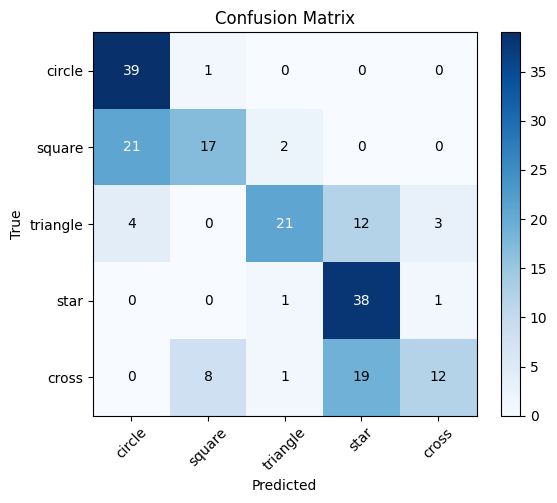

In [4]:
if TF_AVAILABLE:
    probs = model.predict(X_test_cnn, verbose=0)
    preds = probs.argmax(axis=1)
    confidences = probs.max(axis=1)

    overall_acc = (preds == y_test_idx).mean()
    print(f"Overall test accuracy: {overall_acc:.2%}\n")

    print("Per-class accuracy:")
    for i, cls in enumerate(CLASSES):
        mask = y_test_idx == i
        cls_acc = (preds[mask] == y_test_idx[mask]).mean() if mask.sum() > 0 else float("nan")
        print(f"  {cls:<10} {cls_acc:.2%}")

    cm = confusion_matrix(y_test_idx, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45)
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_title("Confusion Matrix")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()


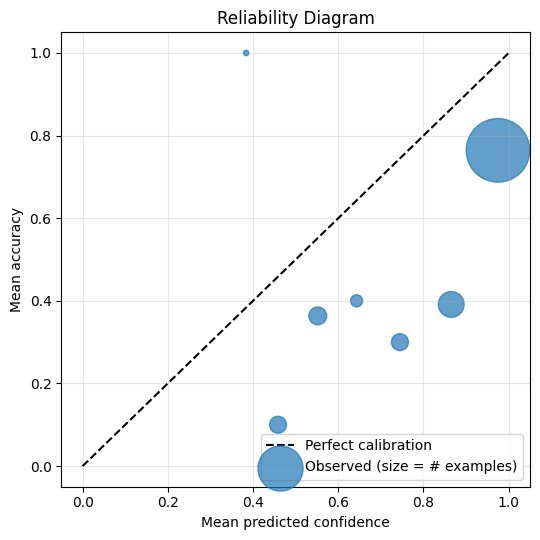

Mean confidence: 89.04%  |  Overall accuracy: 63.50%
Calibration gap: +25.54% (overconfident)


In [5]:
if TF_AVAILABLE:
    # Reliability diagram: bin predictions by confidence decile, plot mean accuracy vs mean confidence
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_accs, bin_confs, bin_counts = [], [], []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confidences >= lo) & (confidences < hi)
        if mask.sum() > 0:
            bin_accs.append((preds[mask] == y_test_idx[mask]).mean())
            bin_confs.append(confidences[mask].mean())
            bin_counts.append(mask.sum())

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.scatter(bin_confs, bin_accs, s=[c * 15 for c in bin_counts], alpha=0.7, label="Observed (size = # examples)")
    ax.set_xlabel("Mean predicted confidence"); ax.set_ylabel("Mean accuracy")
    ax.set_title("Reliability Diagram"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    mean_conf = confidences.mean()
    print(f"Mean confidence: {mean_conf:.2%}  |  Overall accuracy: {overall_acc:.2%}")
    print(f"Calibration gap: {mean_conf - overall_acc:+.2%} ({'overconfident' if mean_conf > overall_acc else 'underconfident'})")


**Answer in this cell:** How large is the gap between validation accuracy and test accuracy? Is the model overconfident, underconfident, or approximately calibrated? Which classes have the lowest accuracy, and is there a pattern in their visual similarity to the classes they are most often confused with?

## Part 2 — Systematic Error Examination

Collect all test set misclassifications, sample some at random, and identify common error patterns.

Total misclassifications: 73 / 200


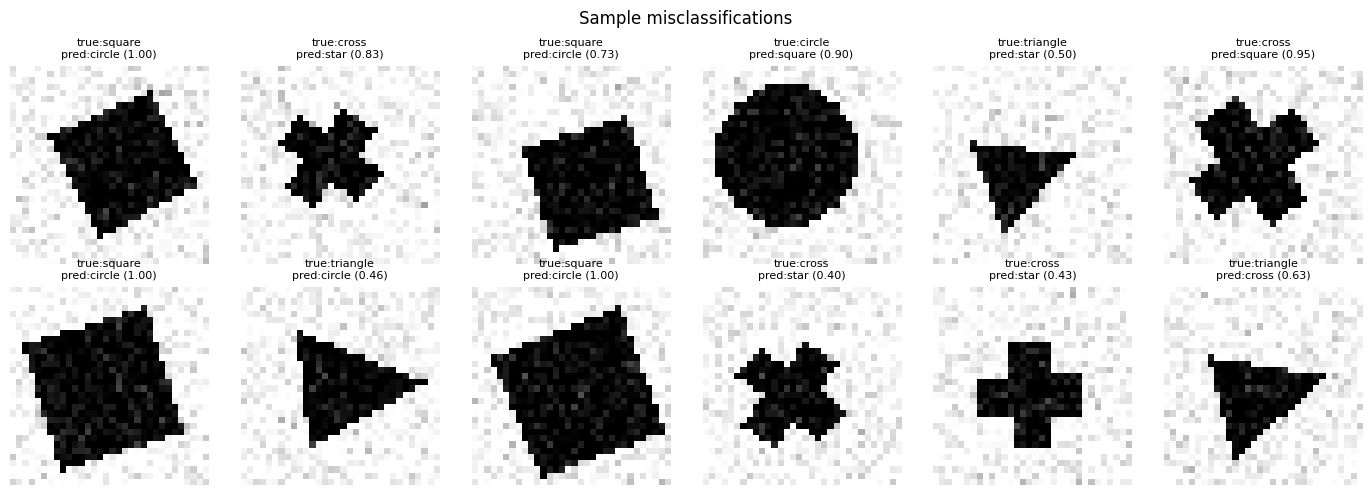


Most common error patterns (true -> predicted):
  square -> circle: 21 times
  cross -> star: 19 times
  triangle -> star: 12 times


In [6]:
if TF_AVAILABLE:
    misclassified_idx = np.where(preds != y_test_idx)[0]
    print(f"Total misclassifications: {len(misclassified_idx)} / {len(y_test_idx)}")

    sample_n = min(12, len(misclassified_idx))
    if sample_n > 0:
        sample_idx = np.random.RandomState(SEED).choice(misclassified_idx, sample_n, replace=False)
        fig, axes = plt.subplots(2, 6, figsize=(14, 5))
        for ax, idx in zip(axes.flat, sample_idx):
            ax.imshow(X_test_imgs[idx], cmap="gray")
            true_cls, pred_cls = CLASSES[y_test_idx[idx]], CLASSES[preds[idx]]
            ax.set_title(f"true:{true_cls}\npred:{pred_cls} ({confidences[idx]:.2f})", fontsize=8)
            ax.axis("off")
        plt.suptitle("Sample misclassifications")
        plt.tight_layout()
        plt.show()

        # Most common (true, predicted) confusion pairs
        from collections import Counter
        pairs = Counter((CLASSES[y_test_idx[i]], CLASSES[preds[i]]) for i in misclassified_idx)
        print("\nMost common error patterns (true -> predicted):")
        for (true_c, pred_c), count in pairs.most_common(3):
            print(f"  {true_c} -> {pred_c}: {count} times")
    else:
        print("No misclassifications found on this run -- try increasing test set difficulty (the `hard=True` split) to get a more instructive error set.")


**For each common error pattern, write one hypothesis about what feature the model may be attending to incorrectly.** Then, revisit the GradCAM function from Chapter 4 and apply it to a few of the most confidently-wrong predictions above. Do the heatmaps support or contradict your hypotheses?

## Part 3 — Representation Visualization

Extract embedding vectors for the full test set from the model's penultimate layer, run t-SNE, and produce a 2D scatter plot colored by true class label.

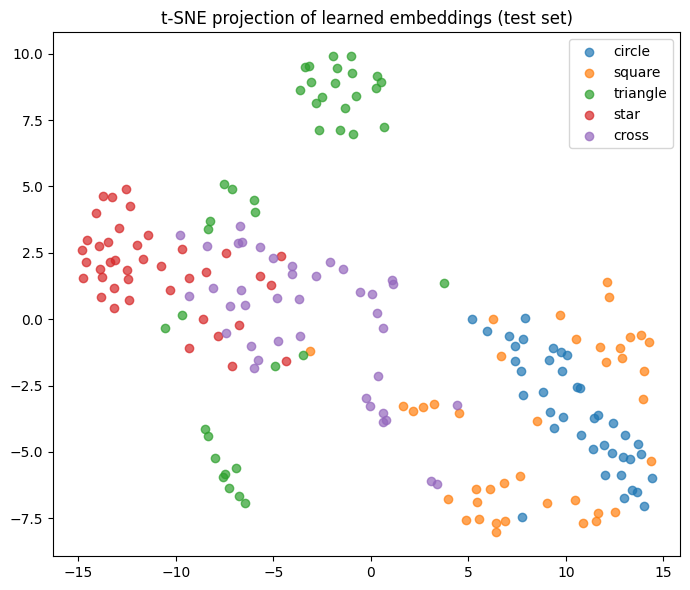

In [7]:
if TF_AVAILABLE:
    embedding_model = tf.keras.models.Model(inputs=model.inputs, outputs=model.get_layer("dense_features").output)
    embeddings = embedding_model.predict(X_test_cnn, verbose=0)

    tsne = TSNE(n_components=2, perplexity=min(30, len(embeddings) // 3), random_state=SEED, init="pca")
    proj = tsne.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(7, 6))
    for i, cls in enumerate(CLASSES):
        mask = y_test_idx == i
        ax.scatter(proj[mask, 0], proj[mask, 1], label=cls, alpha=0.7)
    ax.set_title("t-SNE projection of learned embeddings (test set)")
    ax.legend()
    plt.tight_layout()
    plt.show()


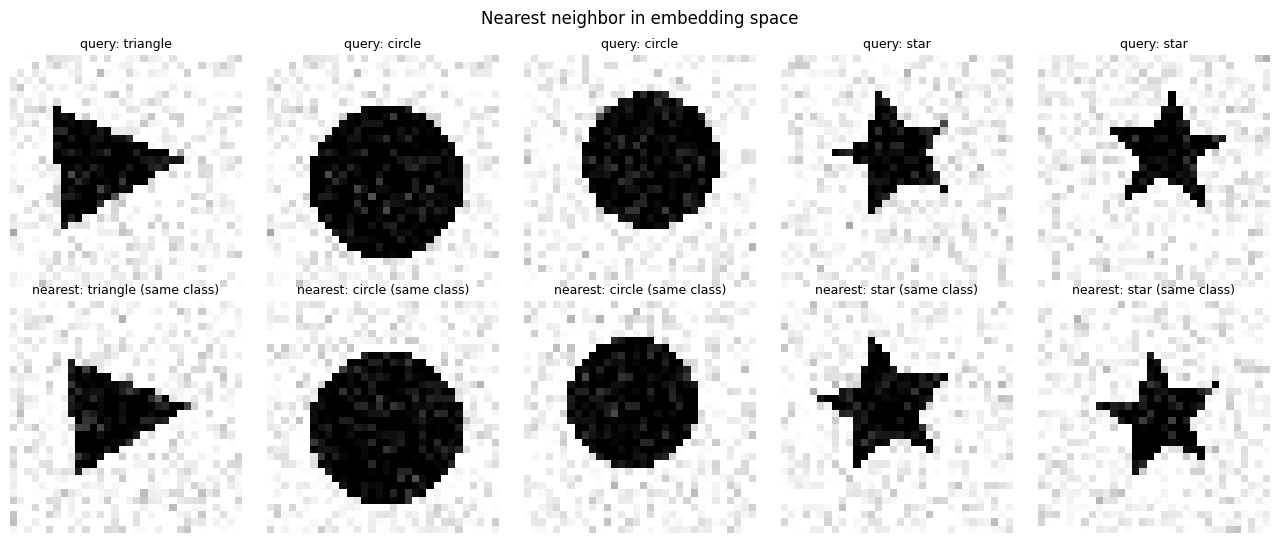

In [8]:
if TF_AVAILABLE:
    # Nearest-neighbor check: for 5 random test images, find their closest neighbor in embedding space
    from sklearn.metrics import pairwise_distances

    dist_matrix = pairwise_distances(embeddings)
    np.fill_diagonal(dist_matrix, np.inf)

    rng = np.random.RandomState(SEED)
    check_idx = rng.choice(len(embeddings), 5, replace=False)

    fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
    for col, idx in enumerate(check_idx):
        nn_idx = dist_matrix[idx].argmin()
        axes[0, col].imshow(X_test_imgs[idx], cmap="gray")
        axes[0, col].set_title(f"query: {CLASSES[y_test_idx[idx]]}", fontsize=9)
        axes[0, col].axis("off")
        axes[1, col].imshow(X_test_imgs[nn_idx], cmap="gray")
        match = "same class" if y_test_idx[nn_idx] == y_test_idx[idx] else "DIFFERENT class"
        axes[1, col].set_title(f"nearest: {CLASSES[y_test_idx[nn_idx]]} ({match})", fontsize=9)
        axes[1, col].axis("off")
    plt.suptitle("Nearest neighbor in embedding space")
    plt.tight_layout()
    plt.show()


**Answer in this cell:** Do same-class images cluster together in the t-SNE plot? Are there any unexpected inter-class or intra-class structures? For any queries above whose nearest neighbor was from a different class, what visual feature does the embedding appear to be using to determine similarity?

## Part 4 — Write the Model Card

Using the template below, write a complete model card for your (or this notebook's) vision module. All fields must be completed with your actual model's real characteristics — no placeholder text. Be honest about limitations.

In [9]:
# This cell computes the real numbers you need to complete the model card below.
if TF_AVAILABLE:
    worst_class_idx = np.argmin([
        (preds[y_test_idx == i] == i).mean() if (y_test_idx == i).sum() > 0 else 1.0
        for i in range(len(CLASSES))
    ])
    print(f"Overall accuracy:        {overall_acc:.2%}")
    print(f"Weakest class:           {CLASSES[worst_class_idx]}")
    print(f"Mean confidence:         {mean_conf:.2%}")
    print(f"Calibration gap:         {mean_conf - overall_acc:+.2%}")
    print(f"Most common error:       {pairs.most_common(1)[0] if misclassified_idx.size else 'none observed'}")


Overall accuracy:        63.50%
Weakest class:           cross
Mean confidence:         89.04%
Calibration gap:         +25.54%
Most common error:       (('square', 'circle'), 21)


**Model Card — MIPDS Vision Module (edit this cell with your real numbers from above):**

| Field | Value |
|---|---|
| Model name / version | _e.g. MIPDS-Vision-CNN-v1_ |
| Intended use | _..._ |
| Training data | _..._ |
| Overall test accuracy | _..._ |
| Weakest performing class(es) | _..._ |
| Calibration | _overconfident / underconfident / well-calibrated, with the gap value_ |
| Known failure modes | _..._ |
| Out-of-scope uses | _..._ |
| Ethical considerations | _..._ |

Exchange model cards with a classmate and review theirs. Identify one limitation they listed that you think is more serious than their framing suggests, and one potential use case they may not have considered.

## Part 5 — The Interface Specification

Complete the interface specification for your MIPDS vision module: input format requirements, all output types and formats, actual performance numbers from Part 1, and the two most important known limitations from Part 2.

**Interface Specification (edit this cell):**

- **Input format:** _e.g. 32x32 grayscale images, normalized to [0,1]_
- **Output: classification** — format and confidence range observed
- **Output: feature vector** — dimensions, intended downstream consumer
- **Performance guarantee** — the specific accuracy number from Part 1, written as a guarantee: "This module achieves ___% accuracy on ___ under ___ conditions."
- **Known limitations affecting downstream use** — the two most consequential limitations from Part 2

Write one closing paragraph (3-4 sentences) addressed to your future self, working on multimodal fusion later in the course: what assumptions is the downstream component allowed to make about this module's outputs, and what must it not assume?